In [54]:

import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.kernel_ridge import KernelRidge
import warnings
warnings.filterwarnings('ignore')


In [71]:
# Charger le dataset
Dataset = pd.read_csv("vinted_data.csv", sep=',', decimal=',')

Dataset.head()
Dataset.info()
Dataset.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   url         384 non-null    str    
 1   etat        384 non-null    str    
 2   matiere     33 non-null     str    
 3   couleur     384 non-null    str    
 4   date        384 non-null    str    
 5   categorie   384 non-null    str    
 6   pays        262 non-null    str    
 7   likes       378 non-null    float64
 8   prix        384 non-null    str    
 9   prix_total  384 non-null    str    
 10  collection  384 non-null    str    
dtypes: float64(1), str(10)
memory usage: 33.1 KB


url             0
etat            0
matiere       351
couleur         0
date            0
categorie       0
pays          122
likes           6
prix            0
prix_total      0
collection      0
dtype: int64

In [72]:
print(Dataset.shape)

(384, 11)


In [73]:
# Remplacer les valeurs manquantes de la colonne "matiere" par "Non précisée"
Dataset["matiere"] = Dataset["matiere"].fillna("Non précisée")

In [74]:
# Remplacer les valeurs manquantes de la colonne "pays" par "Inconnu"
Dataset["pays"] = Dataset["pays"].fillna("Inconnu")

In [75]:
# Remplacer les valeurs manquantes de la colonne "likes" par 0
Dataset["likes"] = Dataset["likes"].fillna(0)


In [51]:
print(Dataset.isnull().sum())

url           0
etat          0
matiere       0
couleur       0
date          0
categorie     0
pays          0
likes         0
prix          0
prix_total    0
collection    0
dtype: int64


In [76]:
# Convertir les colonnes "likes", "prix" et "prix_total" en numérique, en remplaçant les valeurs non convertibles par NaN
Dataset["prix"] = (
    Dataset["prix"]
    .astype(str)
    .str.replace("\u202f", "", regex=False)
    .str.replace("\xa0", "", regex=False)
    .str.replace("€", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

Dataset["prix"] = pd.to_numeric(Dataset["prix"], errors="coerce")
Dataset["prix_total"] = (
    Dataset["prix_total"]
    .astype(str)
    .str.replace("\u202f", "", regex=False)
    .str.replace("\xa0", "", regex=False)
    .str.replace("€", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

Dataset["prix_total"] = pd.to_numeric(Dataset["prix_total"], errors="coerce")

In [78]:
#date de publication

def convertir_date_en_jours(texte):
    '''
    Convertit une date en jours.
    '''
    texte = texte.lower()
    
    # heures -> 0 jour
    if "heure" in texte:
        return 0
    
    # jours
    elif "jour" in texte:
        nombre = re.search(r"\d+", texte)
        
        if nombre:
            return int(nombre.group())
        
        # cas "un jour"
        elif "un" in texte:
            return 1
    
    # mois
    elif "mois" in texte:
        nombre = re.search(r"\d+", texte)
        
        if nombre:
            return int(nombre.group()) * 30
        
        elif "un" in texte:
            return 30
    

    return None

In [79]:
Dataset['date']=Dataset['date'].apply(convertir_date_en_jours)

In [80]:
Dataset.head()

,url,etat,matiere,couleur,date,categorie,pays,likes,prix,prix_total,collection
0,https://www.vinted.fr/items/8878361301-sans-ma...,Neuf sans étiquette,Non précisée,"Crème, Noir",0.0,Sweats et sweats à capuche,"Combourg, France",21.0,7.0,7.70,femme
1,https://www.vinted.fr/items/8878321166-robe-lo...,Très bon état,Coton,Blanc,0.0,Robes,"Fresnes, France",58.0,22.0,23.80,femme
2,https://www.vinted.fr/items/8866538965-jean-bl...,Très bon état,Non précisée,Bleu,1.0,Jeans,Inconnu,24.0,15.0,16.40,femme
3,https://www.vinted.fr/items/8875283926-total-l...,Neuf sans étiquette,"Coton, Lin",Beige,0.0,Blazers et tailleurs,Inconnu,62.0,35.0,37.45,femme
4,https://www.vinted.fr/items/8878420953-robe-lo...,Très bon état,Non précisée,Gris,0.0,Robes,Inconnu,38.0,22.0,23.97,femme


In [ ]:
Dataset.to_csv("vinted_data_clean.csv", index=False)
dataset_clean = pd.read_csv("dataset_clean.csv", sep=',')

In [82]:
# Afficher les statistiques descriptives, la forme du dataset et le nombre de valeurs manquantes
print(dataset_clean.shape)
print(dataset_clean.isnull().sum())

(384, 11)
url           0
etat          0
matiere       0
couleur       0
date          3
categorie     0
pays          0
likes         0
prix          0
prix_total    0
collection    0
dtype: int64


In [83]:
dataset_clean.describe()

,date,likes,prix,prix_total
count,381.000000,384.000000,384.000000,384.000000
mean,1.320210,35.822917,10.279896,11.419193
std,23.051369,30.784773,7.595994,8.063957
min,0.000000,0.000000,1.000000,1.420000
25%,0.000000,18.000000,5.000000,5.950000
50%,0.000000,28.000000,8.000000,9.005000
75%,0.000000,44.000000,14.250000,15.645000
max,450.000000,217.000000,55.000000,59.200000


In [84]:
dataset_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   url         384 non-null    str    
 1   etat        384 non-null    str    
 2   matiere     384 non-null    str    
 3   couleur     384 non-null    str    
 4   date        381 non-null    float64
 5   categorie   384 non-null    str    
 6   pays        384 non-null    str    
 7   likes       384 non-null    float64
 8   prix        384 non-null    float64
 9   prix_total  384 non-null    float64
 10  collection  384 non-null    str    
dtypes: float64(4), str(7)
memory usage: 33.1 KB


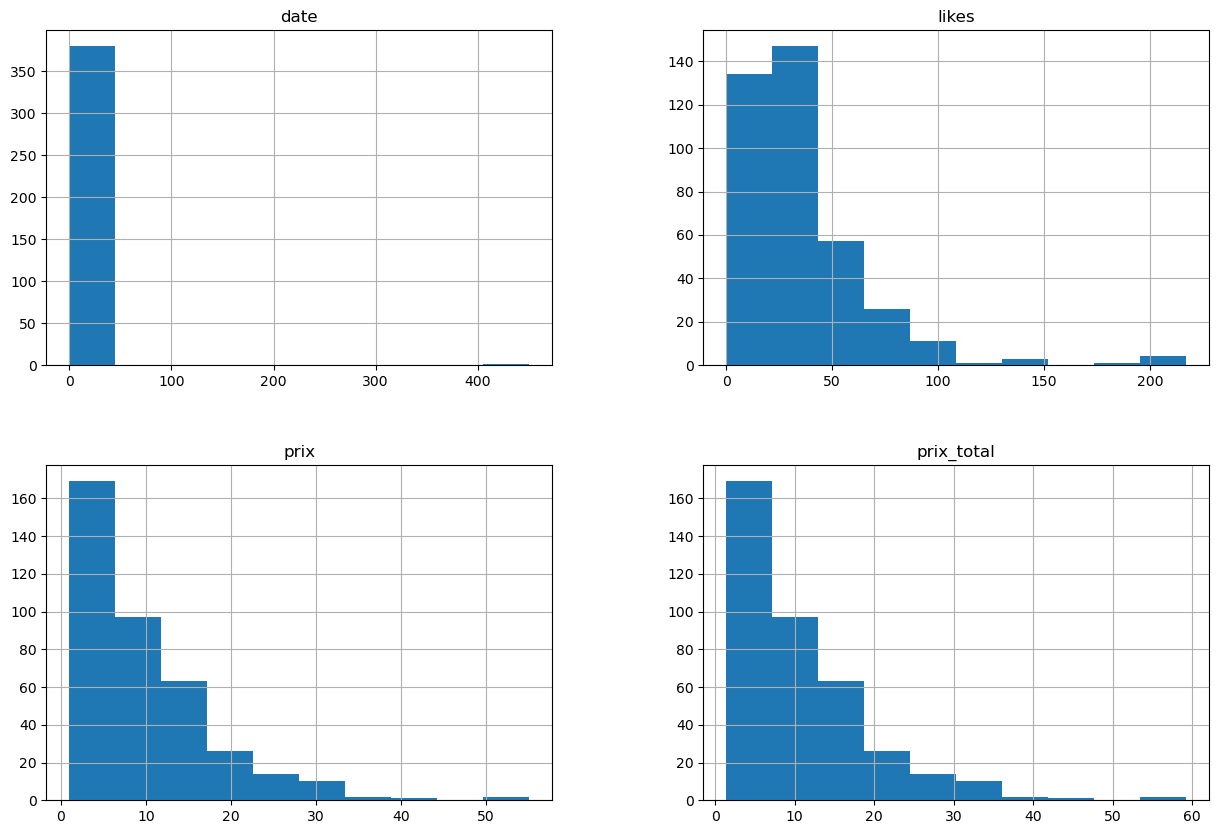

In [85]:
dataset_clean.hist(figsize=(15,10))
plt.show()

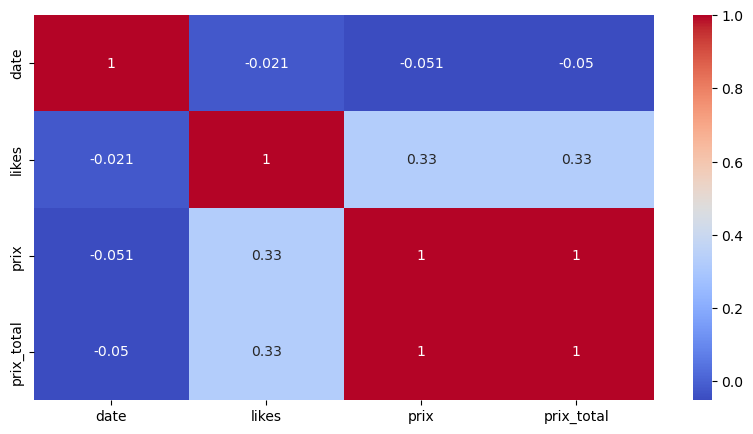

In [86]:
Dataset_numeric = dataset_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(10,5))
sns.heatmap(Dataset_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

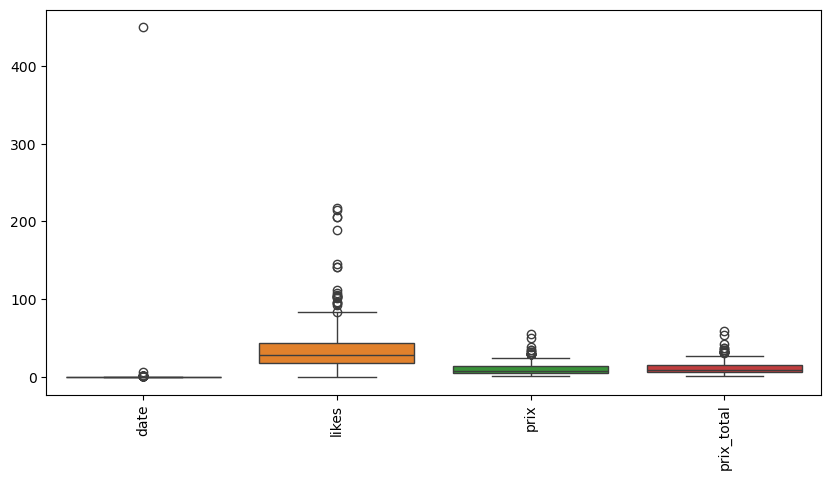

In [87]:
plt.figure(figsize=(10,5))
sns.boxplot(data=dataset_clean.select_dtypes(include=[np.number]))
plt.xticks(rotation=90)
plt.show()